In [33]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [72]:
bins = [0, 54, 69, 180, 250, float('inf')]
labels = ['< 54', '54–69', '70–180', '181–250', '> 250']

def bg_summary(file_path):
    df = pd.read_csv(file_path)
    # Ignore rows that do not follow the regular timestamp format
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    # Ensure BGvalue is numeric, and drop rows with invalid values
    df['BGvalue'] = pd.to_numeric(df['BGvalue'], errors='coerce')
    df = df.dropna(subset=['BGvalue'])
    bg_range = pd.cut(df['BGvalue'], bins=bins, labels=labels, right=True)
    # Count occurrences in each bin
    counts = bg_range.value_counts().reindex(labels, fill_value=0)
    return counts

# Based on days have >= 70% coverage

## OhioT1DM

In [ ]:
# Folder path
# 2018
folder_path_2018_test = '../high_processed_OhioT1DM/2018/test'
folder_path_2018_train = '../high_processed_OhioT1DM/2018/train'
# List all files in the folder
file_names_2018_test = [f for f in os.listdir(folder_path_2018_test) if os.path.isfile(os.path.join(folder_path_2018_test, f))]
file_names_2018_train = [f for f in os.listdir(folder_path_2018_train) if os.path.isfile(os.path.join(folder_path_2018_train, f))]


# 2020
folder_path_2020_test = '../high_processed_OhioT1DM/2020/test'
folder_path_2020_train = '../high_processed_OhioT1DM/2020/train'
file_names_2020_test = [f for f in os.listdir(folder_path_2020_test) if os.path.isfile(os.path.join(folder_path_2020_test, f))]
file_names_2020_train = [f for f in os.listdir(folder_path_2020_train) if os.path.isfile(os.path.join(folder_path_2020_train, f))]


In [44]:
file_names_2020_train

['filtered_567.csv',
 'filtered_552.csv',
 'filtered_584.csv',
 'filtered_544.csv',
 'filtered_540.csv',
 'filtered_596.csv']

In [84]:
# Define bin edges and labels
total_counts_ohio = pd.Series(0, index=labels, dtype=int)

# Loop over DataFrames and accumulate counts
# Process files in the train folder
for input_file in file_names_2018_train:
    # Parse the CSV file
    if input_file != ".DS_Store":
        full_file_path = os.path.join(folder_path_2018_train, input_file)
        count = bg_summary(full_file_path)
        total_counts_ohio += count

for input_file in file_names_2018_test:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2018_test, input_file)
    count = bg_summary(full_file_path)
    total_counts_ohio += count

for input_file in file_names_2020_train:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2020_train, input_file)
    count = bg_summary(full_file_path)
    total_counts_ohio += count    

for input_file in file_names_2020_test:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2020_test, input_file)
    count = bg_summary(full_file_path)
    total_counts_ohio += count

In [85]:
# Calculate the total sum of all counts
total_entries = total_counts_ohio.sum()

# Calculate the ratio for each group
ratios = total_counts_ohio / total_entries

# Convert ratios to percentages for better readability
ratios_percentage_ohio = ratios * 100

# Print the results
print("Ratios (as percentages):")
print(ratios_percentage_ohio)

Ratios (as percentages):
< 54        0.678113
54–69       2.433721
70–180     63.389015
181–250    25.274697
> 250       8.224455
dtype: float64


## T1DEXI

In [ ]:
folder_path_t1dexi = '../high_processed_T1DEXI/'
file_names_t1dexi= [f for f in os.listdir(folder_path_t1dexi) if os.path.isfile(os.path.join(folder_path_t1dexi, f))]

# Define bin edges and labels
total_counts_t1dexi = pd.Series(0, index=labels, dtype=int)
for input_file in file_names_t1dexi:
    full_file_path = os.path.join(folder_path_t1dexi, input_file)

    count = bg_summary(full_file_path)
    total_counts_t1dexi += count

total_counts_t1dexi

< 54         25195
54–69        88574
70–180     2792476
181–250     624400
> 250       203057
dtype: int64

In [87]:
# Calculate the total sum of all counts
total_entries = total_counts_t1dexi.sum()

# Calculate the ratio for each group
ratios = total_counts_t1dexi / total_entries

# Convert ratios to percentages for better readability
ratios_percentage_t1dexi = ratios * 100

# Print the results
print("Ratios (as percentages):")
print(ratios_percentage_t1dexi)

Ratios (as percentages):
< 54        0.674799
54–69       2.372284
70–180     74.791079
181–250    16.723349
> 250       5.438490
dtype: float64


## BIL

In [ ]:
folder_path_bil = '../high_processed_BIL/'
file_names_bil= [f for f in os.listdir(folder_path_bil) if os.path.isfile(os.path.join(folder_path_bil, f))]
# Define bin edges and labels
total_counts_bil = pd.Series(0, index=labels, dtype=int)
for input_file in file_names_bil:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_bil, input_file)
    count = bg_summary(full_file_path)
    total_counts_bil += count

total_counts_bil

< 54          25
54–69        152
70–180     31734
181–250      580
> 250          7
dtype: int64

In [89]:
# Calculate the total sum of all counts
total_entries = total_counts_bil.sum()

# Calculate the ratio for each group
ratios = total_counts_bil / total_entries

# Convert ratios to percentages for better readability
ratios_percentage_bil = ratios * 100

# Print the results
print("Ratios (as percentages):")
print(ratios_percentage_bil)

Ratios (as percentages):
< 54        0.076928
54–69       0.467721
70–180     97.649086
181–250     1.784725
> 250       0.021540
dtype: float64


## T1DiabetesGranada

In [ ]:
folder_path_T1DiabetesGranada= '../high_processed_T1DiabetesGranada/'
file_names_T1DiabetesGranada= [f for f in os.listdir(folder_path_T1DiabetesGranada) if os.path.isfile(os.path.join(folder_path_T1DiabetesGranada, f))]

total_counts_T1DiabetesGranada = pd.Series(0, index=labels, dtype=int)

for input_file in file_names_T1DiabetesGranada:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_T1DiabetesGranada, input_file)
    count = bg_summary(full_file_path)
    total_counts_T1DiabetesGranada += count

total_counts_T1DiabetesGranada

< 54         252084
54–69        764212
70–180     12927062
181–250     5119737
> 250       2466408
dtype: int64

In [91]:
# Calculate the total sum of all counts
total_entries = total_counts_T1DiabetesGranada.sum()

# Calculate the ratio for each group
ratios = total_counts_T1DiabetesGranada / total_entries

# Convert ratios to percentages for better readability
ratios_percentage_granada = ratios * 100

# Print the results
print("Ratios (as percentages):")
print(ratios_percentage_granada)

Ratios (as percentages):
< 54        1.170877
54–69       3.549604
70–180     60.043476
181–250    23.780098
> 250      11.455945
dtype: float64


## UCHTT1DM

In [ ]:
folder_path_uchtt1dm= '../high_processed_UCHTT1DM/'
file_names_uchtt1dm= [f for f in os.listdir(folder_path_uchtt1dm) if os.path.isfile(os.path.join(folder_path_uchtt1dm, f))]
total_counts_uchtt1dm = pd.Series(0, index=labels, dtype=int)

for input_file in file_names_uchtt1dm:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_uchtt1dm, input_file)
    count = bg_summary(full_file_path)
    total_counts_uchtt1dm += count

total_counts_uchtt1dm


< 54         252
54–69       1058
70–180     22476
181–250     1638
> 250        479
dtype: int64

In [93]:
# Calculate the total sum of all counts
total_entries = total_counts_uchtt1dm.sum()

# Calculate the ratio for each group
ratios = total_counts_uchtt1dm / total_entries

# Convert ratios to percentages for better readability
ratios_percentage_uchtt1dm = ratios * 100

# Print the results
print("Ratios (as percentages):")
print(ratios_percentage_uchtt1dm)

Ratios (as percentages):
< 54        0.972860
54–69       4.084469
70–180     86.769872
181–250     6.323592
> 250       1.849207
dtype: float64


# DiaTrend

In [ ]:
folder_path_diatrend= '../high_processed_Diatrend/'
file_names_diatrend= [f for f in os.listdir(folder_path_diatrend) if os.path.isfile(os.path.join(folder_path_diatrend, f))]
total_counts_diatrend = pd.Series(0, index=labels, dtype=int)

for input_file in file_names_diatrend:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_diatrend, input_file)
    count = bg_summary(full_file_path)
    total_counts_diatrend += count

total_counts_diatrend


< 54         35100
54–69        96362
70–180     3734403
181–250    2091831
> 250      1371235
dtype: int64

In [95]:
# Calculate the total sum of all counts
total_entries = total_counts_diatrend.sum()

# Calculate the ratio for each group
ratios = total_counts_diatrend / total_entries

# Convert ratios to percentages for better readability
ratios_percentage_diatrend = ratios * 100

# Print the results
print("Ratios (as percentages):")
print(ratios_percentage_diatrend)

Ratios (as percentages):
< 54        0.478924
54–69       1.314817
70–180     50.954266
181–250    28.542103
> 250      18.709891
dtype: float64


# ShanghaiT1DM

In [ ]:
folder_path_shanghait1= '../high_processed_shanghait1dm/'
file_names_shanghait1= [f for f in os.listdir(folder_path_shanghait1) if os.path.isfile(os.path.join(folder_path_shanghait1, f))]
total_counts_shanghait1 = pd.Series(0, index=labels, dtype=int)

for input_file in file_names_shanghait1:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_shanghait1, input_file)
    count = bg_summary(full_file_path)
    total_counts_shanghait1 += count

total_counts_shanghait1

< 54        440
54–69       681
70–180     7733
181–250    3677
> 250      1959
dtype: int64

In [97]:
# Calculate the total sum of all counts
total_entries = total_counts_shanghait1.sum()

# Calculate the ratio for each group
ratios = total_counts_shanghait1 / total_entries

# Convert ratios to percentages for better readability
ratios_percentage_shanghait1 = ratios * 100

# Print the results
print("Ratios (as percentages):")
print(ratios_percentage_shanghait1)

Ratios (as percentages):
< 54        3.036577
54–69       4.699793
70–180     53.367840
181–250    25.376121
> 250      13.519669
dtype: float64


# ShanghaiT2DM

In [ ]:
folder_path_shanghait2= '../high_processed_shanghait2dm/'
file_names_shanghait2= [f for f in os.listdir(folder_path_shanghait2) if os.path.isfile(os.path.join(folder_path_shanghait2, f))]
total_counts_shanghait2 = pd.Series(0, index=labels, dtype=int)

for input_file in file_names_shanghait2:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_shanghait2, input_file)
    count = bg_summary(full_file_path)
    total_counts_shanghait2 += count

total_counts_shanghait2

< 54         796
54–69       1473
70–180     82858
181–250    15602
> 250       3823
dtype: int64

In [99]:
# Calculate the total sum of all counts
total_entries = total_counts_shanghait2.sum()

# Calculate the ratio for each group
ratios = total_counts_shanghait2 / total_entries

# Convert ratios to percentages for better readability
ratios_percentage_shanghait2 = ratios * 100

# Print the results
print("Ratios (as percentages):")
print(ratios_percentage_shanghait2)

Ratios (as percentages):
< 54        0.761344
54–69       1.408868
70–180     79.250516
181–250    14.922718
> 250       3.656554
dtype: float64


# AI-READI

In [ ]:
folder_path_aireadi= '../high_processed_aireadi/'
file_names_aireadi= [f for f in os.listdir(folder_path_aireadi) if os.path.isfile(os.path.join(folder_path_aireadi, f))]
total_counts_aireadi = pd.Series(0, index=labels, dtype=int)

for input_file in file_names_aireadi:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_aireadi, input_file)
    count = bg_summary(full_file_path)
    total_counts_aireadi += count

total_counts_aireadi

< 54          2848
54–69        11947
70–180     2371638
181–250     270432
> 250        93638
dtype: int64

In [101]:
# Calculate the total sum of all counts
total_entries = total_counts_aireadi.sum()

# Calculate the ratio for each group
ratios = total_counts_aireadi / total_entries

# Convert ratios to percentages for better readability
ratios_percentage_aireadi = ratios * 100

# Print the results
print("Ratios (as percentages):")
print(ratios_percentage_aireadi)

Ratios (as percentages):
< 54        0.103545
54–69       0.434357
70–180     86.225610
181–250     9.832093
> 250       3.404395
dtype: float64


# GCMacros

In [ ]:
folder_path_CGMacros_dexcom = '../11_CGMacros/Dexcom GL'
file_names_CGMacros_dexcom = [f for f in os.listdir(folder_path_CGMacros_dexcom) if os.path.isfile(os.path.join(folder_path_CGMacros_dexcom, f))]
folder_path_CGMacros_libre = '../11_CGMacros/Libre GL'
file_names_CGMacros_libre = [f for f in os.listdir(folder_path_CGMacros_libre) if os.path.isfile(os.path.join(folder_path_CGMacros_libre, f))]

total_counts_CGMacros = pd.Series(0, index=labels, dtype=int)

# Process files in the train folder
for input_file in file_names_CGMacros_dexcom:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_CGMacros_dexcom, input_file)
    count = bg_summary(full_file_path)
    total_counts_CGMacros += count

# Process files in the train folder
for input_file in file_names_CGMacros_libre:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_CGMacros_libre, input_file)
    count = bg_summary(full_file_path)
    total_counts_CGMacros += count

In [103]:
# Calculate the total sum of all counts
total_entries = total_counts_CGMacros.sum()

# Calculate the ratio for each group
ratios = total_counts_CGMacros / total_entries

# Convert ratios to percentages for better readability
ratios_percentage_CGMacros = ratios * 100

# Print the results
print("Ratios (as percentages):")
print(ratios_percentage_CGMacros)

Ratios (as percentages):
< 54        2.101907
54–69       3.130084
70–180     84.644906
181–250     8.306654
> 250       1.816449
dtype: float64


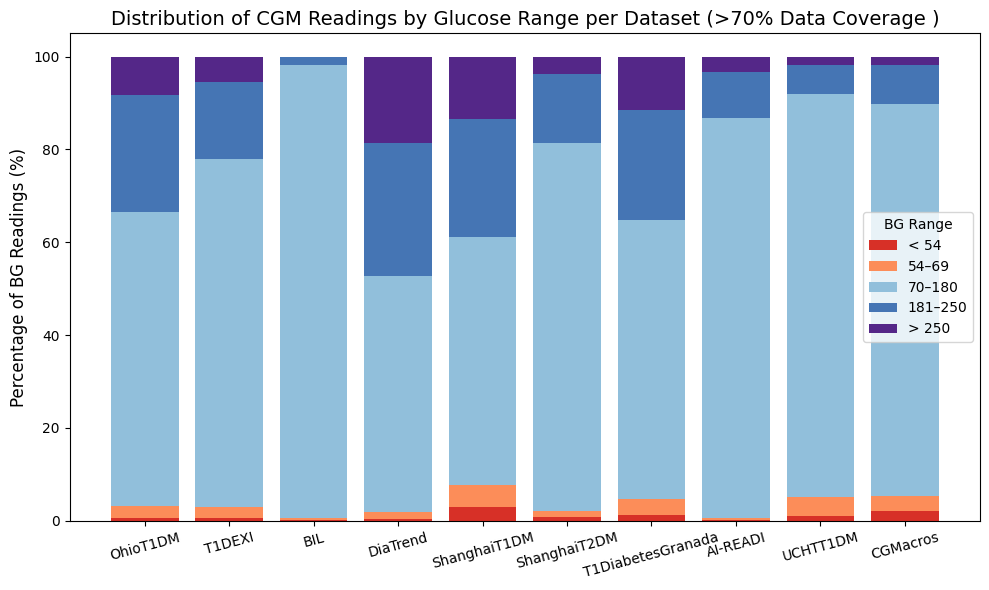

In [104]:
# Combine all into a DataFrame for plotting
df = pd.DataFrame({
    'OhioT1DM': ratios_percentage_ohio,
    'T1DEXI': ratios_percentage_t1dexi,
    'BIL': ratios_percentage_bil,
    'DiaTrend': ratios_percentage_diatrend,
    'ShanghaiT1DM': ratios_percentage_shanghait1,
    'ShanghaiT2DM': ratios_percentage_shanghait2,
    'T1DiabetesGranada': ratios_percentage_granada,
    'AI-READI': ratios_percentage_aireadi,
    'UCHTT1DM': ratios_percentage_uchtt1dm,
    'CGMacros': ratios_percentage_CGMacros,
})

# Ensure the desired order of glucose bins
ordered_ranges = ['< 54', '54–69', '70–180', '181–250', '> 250']
df = df.loc[ordered_ranges]

# Plot setup
fig, ax = plt.subplots(figsize=(10, 6))

# Stacked bar plot
bottom = pd.Series([0] * len(df.columns), index=df.columns)
colors = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4', '#542788']  # Custom colors for layers

for i, range_label in enumerate(df.index):
    ax.bar(df.columns, df.loc[range_label], bottom=bottom, label=range_label, color=colors[i])
    bottom += df.loc[range_label]

# Labels and title
ax.set_ylabel('Percentage of BG Readings (%)', fontsize=12)
ax.set_title('Distribution of CGM Readings by Glucose Range per Dataset (>70% Data Coverage )', fontsize=14)
ax.set_ylim(0, 105)
ax.legend(title='BG Range')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()